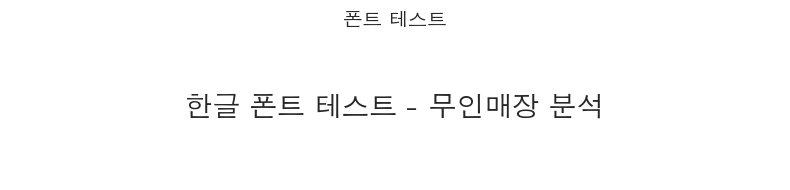

✅ 현재 폰트: ['AppleGothic']


In [13]:
# 필요한 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 한글 폰트 설정 (순서가 중요!)
# ============================================

# 1. 먼저 seaborn 스타일 설정
sns.set_style("whitegrid")

# 2. 그 다음 폰트 설정 (seaborn이 덮어쓰지 않도록)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)

# 테스트 출력
fig, ax = plt.subplots(figsize=(8, 2))
ax.text(0.5, 0.5, '한글 폰트 테스트 - 무인매장 분석', fontsize=20, ha='center', va='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title('폰트 테스트', fontsize=14)
plt.tight_layout()
plt.show()

print(f"✅ 현재 폰트: {plt.rcParams['font.family']}")

In [14]:
# 데이터 로드
df_raw = pd.read_csv('brwnie_stores.csv')

# 실제 매장 데이터만 필터링 (store_name이 있고 si_address가 있는 데이터)
df = df_raw[df_raw['store_name'].notna() & df_raw['si_address'].notna()].copy()

print(f"📊 전체 원본 데이터: {len(df_raw):,}개")
print(f"📊 유효한 매장 데이터: {len(df):,}개")
print(f"\n📋 컬럼 목록:")
print(df.columns.tolist())
print(f"\n📋 데이터 샘플:")
df[['store_name', 'category', 'si_address', 'goon_gu_address']].head()

📊 전체 원본 데이터: 23,650개
📊 유효한 매장 데이터: 23,502개

📋 컬럼 목록:
['src', 'sizes', 'type', 'year', 'month', 'date', 'ymd', 'id', 'store_name', 'created_at', 'category', 'search_key', 'address', 'si_address', 'goon_gu_address', 'latitude', 'longitude', 'contact_number', 'operation_time', 'description', 'brwnie_yn', 'naver_category']

📋 데이터 샘플:


,store_name,category,si_address,goon_gu_address
148,어반런드렛 서초,셀프빨래방,서울특별시,서초구
149,어반런드렛 석촌,셀프빨래방,서울특별시,송파구
150,런드리24 논현점,셀프빨래방,서울특별시,강남구
151,런드리24 언주역점,셀프빨래방,서울특별시,강남구
152,런드리24 역삼1호점,셀프빨래방,서울특별시,강남구


## 1. 기본 통계 요약

In [15]:
# 기본 통계
print("=" * 60)
print("📊 브라우니 무인매장 데이터 기본 통계")
print("=" * 60)

print(f"\n✅ 총 매장 수: {len(df):,}개")
print(f"✅ 시/도 수: {df['si_address'].nunique()}개")
print(f"✅ 구/군 수: {df['goon_gu_address'].nunique()}개")
print(f"✅ 업종 카테고리 수: {df['category'].nunique()}개")

# 브라우니 사용 매장 수
brwnie_count = df[df['brwnie_yn'] == True].shape[0]
print(f"✅ 브라우니 사용 매장: {brwnie_count:,}개 ({brwnie_count/len(df)*100:.1f}%)")

print("\n📋 업종별 매장 수 TOP 10:")
print(df['category'].value_counts().head(10))

📊 브라우니 무인매장 데이터 기본 통계

✅ 총 매장 수: 23,502개
✅ 시/도 수: 15개
✅ 구/군 수: 85개
✅ 업종 카테고리 수: 14개
✅ 브라우니 사용 매장: 464개 (2.0%)

📋 업종별 매장 수 TOP 10:
category
스터디카페       5221
무인카페        4956
셀프빨래방       4115
아이스크림할인점    3348
무인문방구       2577
셀프스튜디오      1528
무인편의점        653
무인펫샵         321
기타           295
무인라면         284
Name: count, dtype: int64


## 2. 시/도별 무인매장 분포

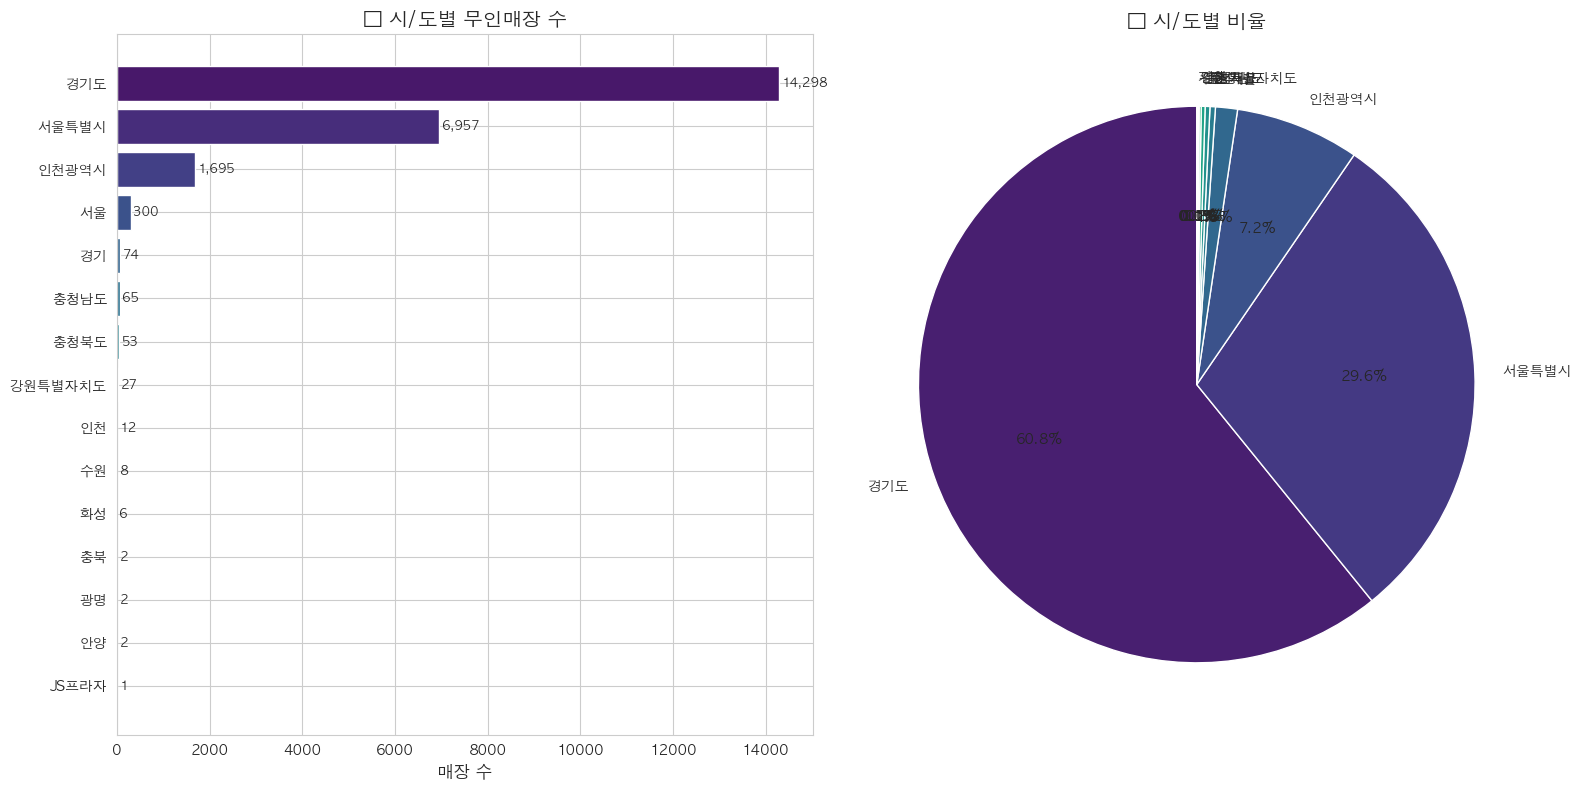


📊 시/도별 매장 수:
si_address
경기도        14298
서울특별시       6957
인천광역시       1695
서울           300
경기            74
충청남도          65
충청북도          53
강원특별자치도       27
인천            12
수원             8
화성             6
충북             2
광명             2
안양             2
JS프라자          1


In [16]:
# 시/도별 매장 수
si_counts = df['si_address'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 막대 그래프
colors = sns.color_palette("viridis", len(si_counts))
bars = axes[0].barh(si_counts.index[::-1], si_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('매장 수', fontsize=12)
axes[0].set_title('📍 시/도별 무인매장 수', fontsize=14, fontweight='bold')

# 값 표시
for bar, val in zip(bars, si_counts.values[::-1]):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)

# 파이 차트 (상위 10개)
top10_si = si_counts.head(10)
others = si_counts[10:].sum()
if others > 0:
    pie_data = pd.concat([top10_si, pd.Series({'기타': others})])
else:
    pie_data = top10_si

axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', 
            colors=sns.color_palette("viridis", len(pie_data)), startangle=90)
axes[1].set_title('📊 시/도별 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 시/도별 매장 수:")
print(si_counts.to_string())

## 3. 업종별 무인매장 분포

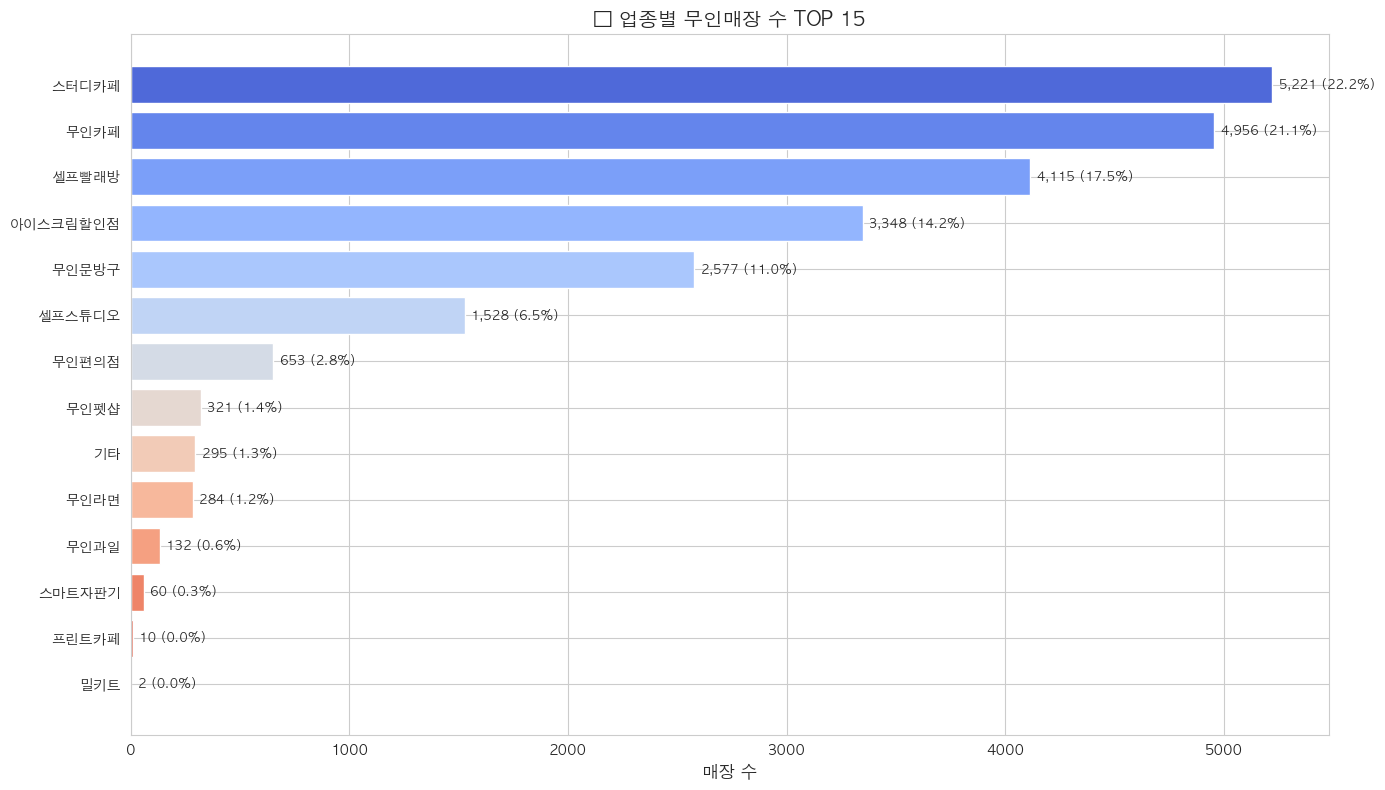


📊 업종별 매장 수 TOP 15:
  스터디카페: 5,221개 (22.2%)
  무인카페: 4,956개 (21.1%)
  셀프빨래방: 4,115개 (17.5%)
  아이스크림할인점: 3,348개 (14.2%)
  무인문방구: 2,577개 (11.0%)
  셀프스튜디오: 1,528개 (6.5%)
  무인편의점: 653개 (2.8%)
  무인펫샵: 321개 (1.4%)
  기타: 295개 (1.3%)
  무인라면: 284개 (1.2%)
  무인과일: 132개 (0.6%)
  스마트자판기: 60개 (0.3%)
  프린트카페: 10개 (0.0%)
  밀키트: 2개 (0.0%)


In [17]:
# 업종별 매장 수 TOP 15
category_counts = df['category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))

colors = sns.color_palette("coolwarm", len(category_counts))
bars = ax.barh(category_counts.index[::-1], category_counts.values[::-1], color=colors[::-1])

ax.set_xlabel('매장 수', fontsize=12)
ax.set_title('🏪 업종별 무인매장 수 TOP 15', fontsize=14, fontweight='bold')

# 값 표시
for bar, val in zip(bars, category_counts.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, 
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📊 업종별 매장 수 TOP 15:")
for cat, cnt in category_counts.items():
    print(f"  {cat}: {cnt:,}개 ({cnt/len(df)*100:.1f}%)")

## 4. 지역별 업종 분포 히트맵

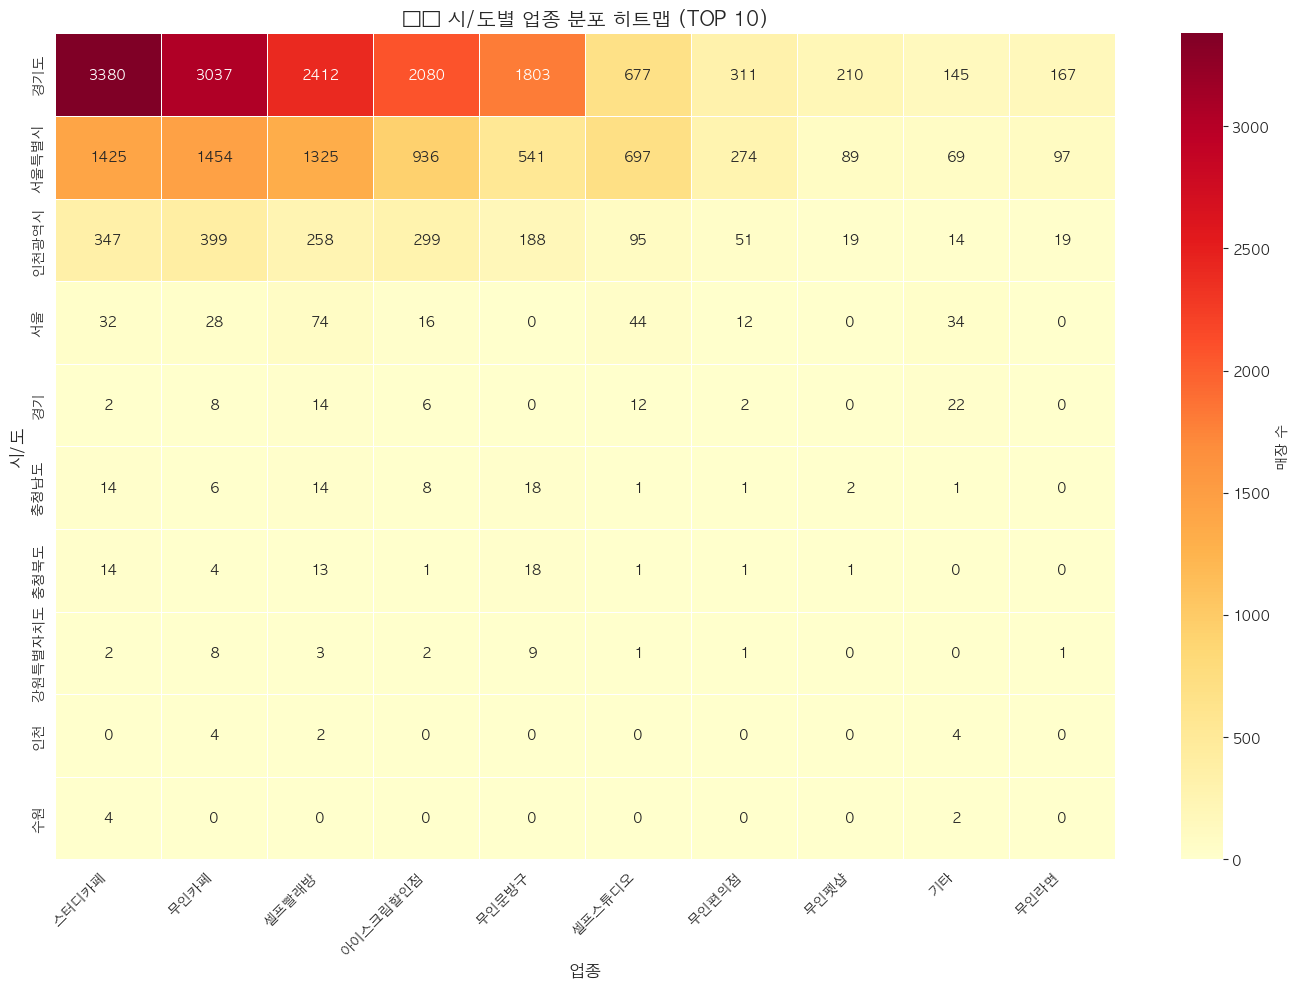

In [18]:
# 시/도별 업종 분포 피벗 테이블 (상위 10개 시도, 상위 10개 업종)
top_si = df['si_address'].value_counts().head(10).index.tolist()
top_cat = df['category'].value_counts().head(10).index.tolist()

df_filtered = df[df['si_address'].isin(top_si) & df['category'].isin(top_cat)]
pivot_table = pd.pivot_table(df_filtered, values='id', index='si_address', 
                              columns='category', aggfunc='count', fill_value=0)

# 정렬
pivot_table = pivot_table.reindex(top_si)
pivot_table = pivot_table[top_cat]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '매장 수'})
ax.set_title('🗺️ 시/도별 업종 분포 히트맵 (TOP 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('업종', fontsize=12)
ax.set_ylabel('시/도', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. 서울시 구별 무인매장 분포

📍 서울시 무인매장: 6,957개


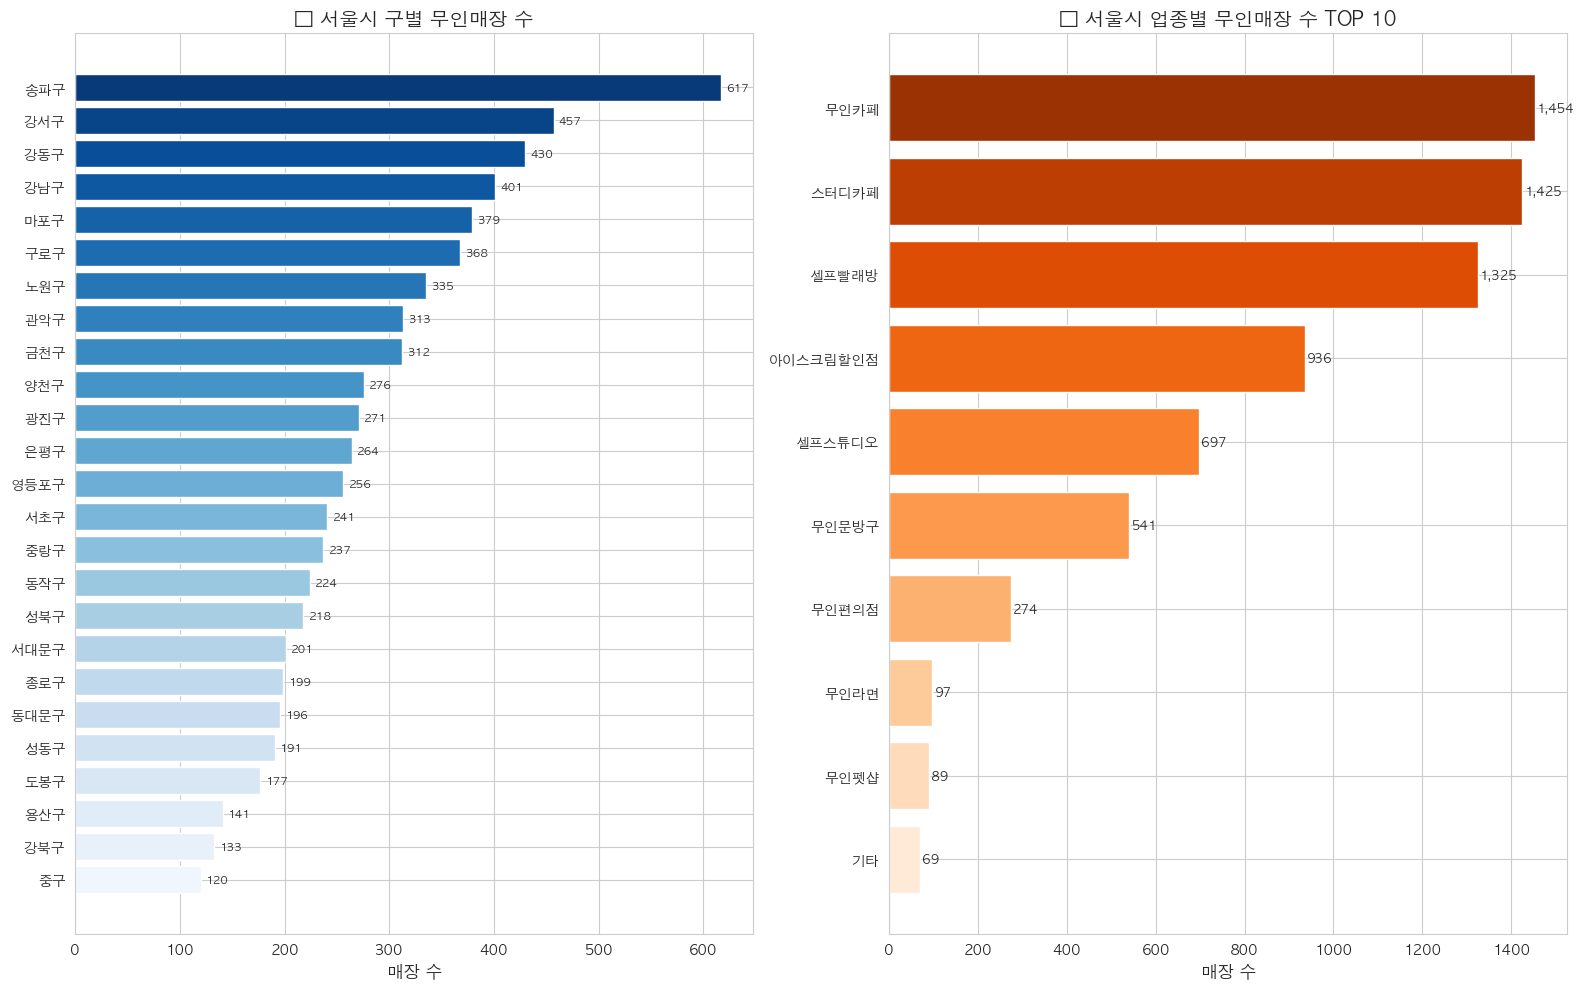

In [19]:
# 서울시 데이터만 추출
df_seoul = df[df['si_address'] == '서울특별시']

print(f"📍 서울시 무인매장: {len(df_seoul):,}개")

# 서울시 구별 분포
gu_counts = df_seoul['goon_gu_address'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 막대 그래프
colors = sns.color_palette("Blues_r", len(gu_counts))
bars = axes[0].barh(gu_counts.index[::-1], gu_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('매장 수', fontsize=12)
axes[0].set_title('📍 서울시 구별 무인매장 수', fontsize=14, fontweight='bold')

for bar, val in zip(bars, gu_counts.values[::-1]):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=8)

# 서울시 업종별 TOP 10
seoul_cat = df_seoul['category'].value_counts().head(10)
colors2 = sns.color_palette("Oranges_r", len(seoul_cat))
bars2 = axes[1].barh(seoul_cat.index[::-1], seoul_cat.values[::-1], color=colors2[::-1])
axes[1].set_xlabel('매장 수', fontsize=12)
axes[1].set_title('🏪 서울시 업종별 무인매장 수 TOP 10', fontsize=14, fontweight='bold')

for bar, val in zip(bars2, seoul_cat.values[::-1]):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. 경기도 시/군별 무인매장 분포

📍 경기도 무인매장: 14,298개


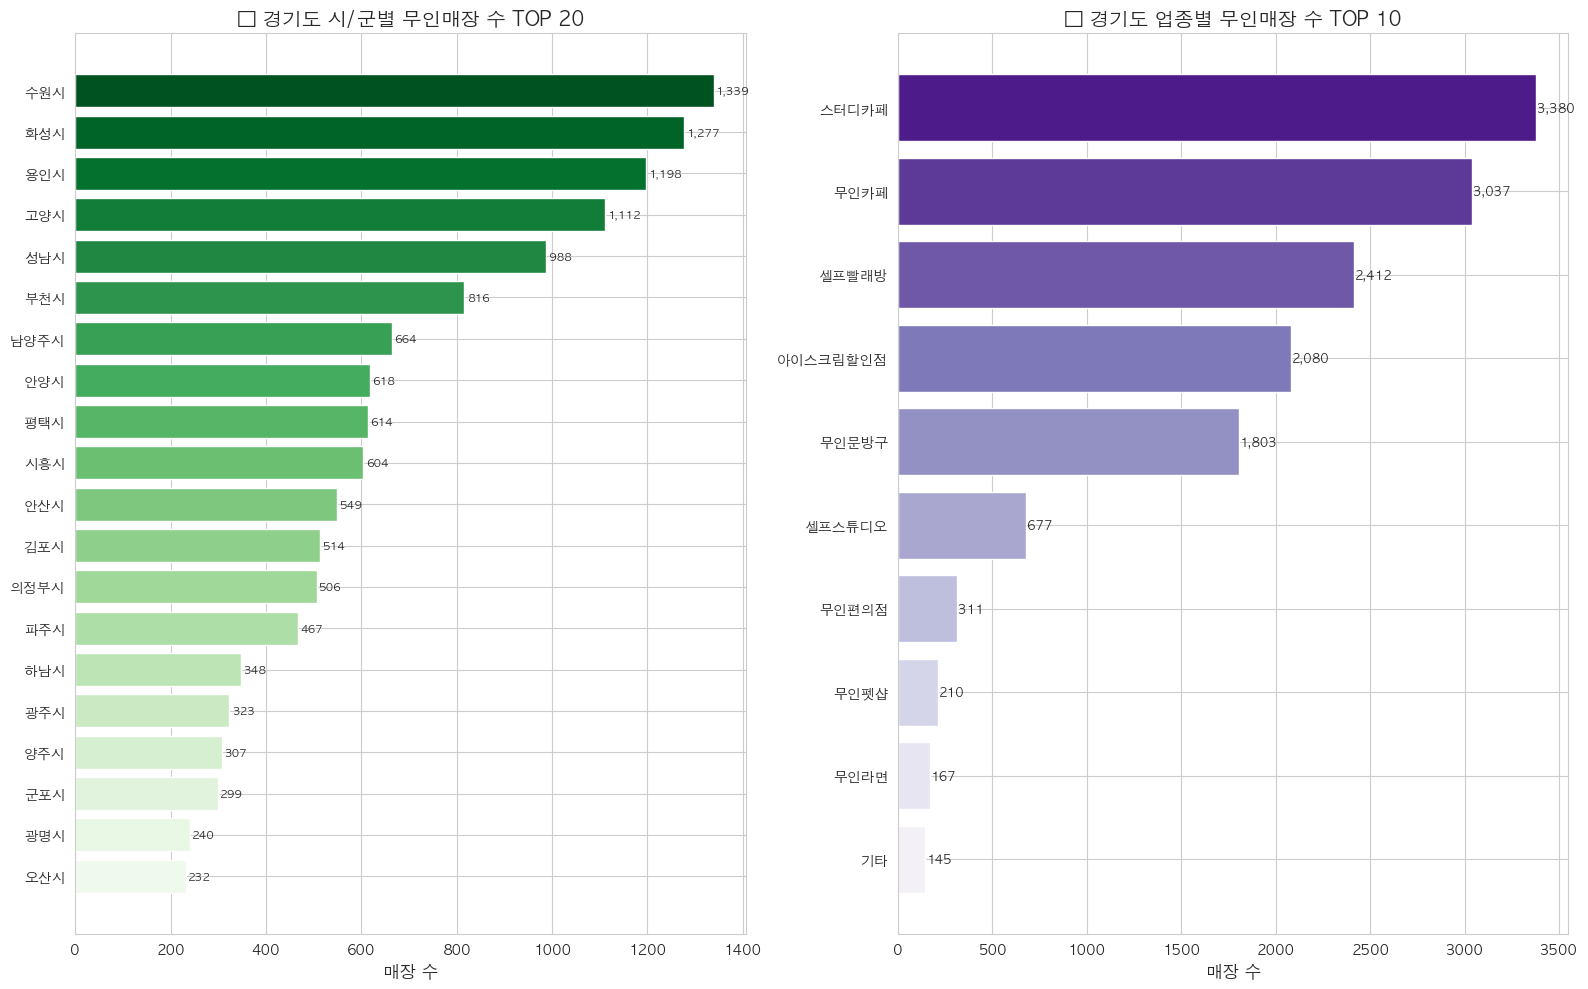

In [20]:
# 경기도 데이터만 추출
df_gg = df[df['si_address'] == '경기도']

print(f"📍 경기도 무인매장: {len(df_gg):,}개")

# 경기도 시/군별 분포 TOP 20
gg_counts = df_gg['goon_gu_address'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 막대 그래프
colors = sns.color_palette("Greens_r", len(gg_counts))
bars = axes[0].barh(gg_counts.index[::-1], gg_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('매장 수', fontsize=12)
axes[0].set_title('📍 경기도 시/군별 무인매장 수 TOP 20', fontsize=14, fontweight='bold')

for bar, val in zip(bars, gg_counts.values[::-1]):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=8)

# 경기도 업종별 TOP 10
gg_cat = df_gg['category'].value_counts().head(10)
colors2 = sns.color_palette("Purples_r", len(gg_cat))
bars2 = axes[1].barh(gg_cat.index[::-1], gg_cat.values[::-1], color=colors2[::-1])
axes[1].set_xlabel('매장 수', fontsize=12)
axes[1].set_title('🏪 경기도 업종별 무인매장 수 TOP 10', fontsize=14, fontweight='bold')

for bar, val in zip(bars2, gg_cat.values[::-1]):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. 주요 업종별 지역 분포 분석

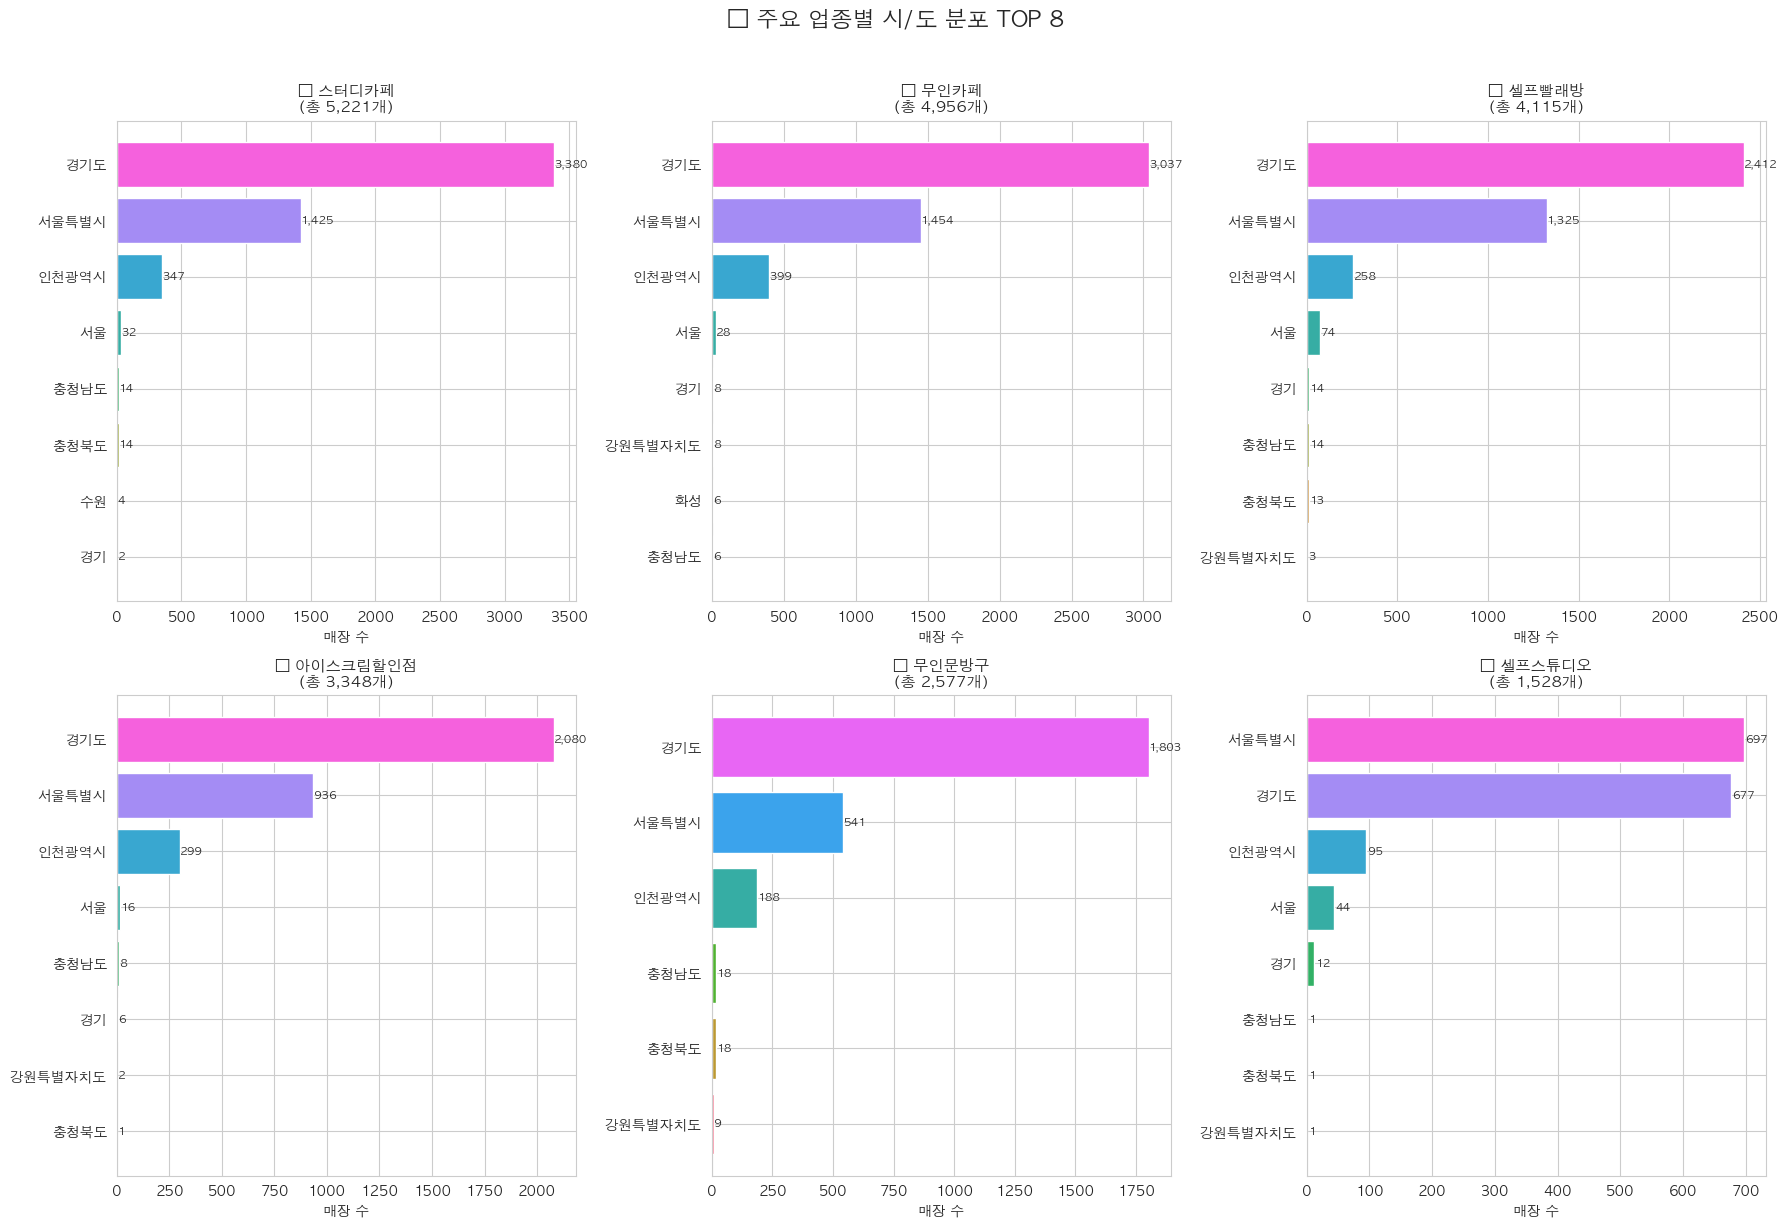

In [21]:
# 상위 6개 업종의 지역별 분포
top6_categories = df['category'].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, cat in enumerate(top6_categories):
    df_cat = df[df['category'] == cat]
    cat_si = df_cat['si_address'].value_counts().head(8)
    
    colors = sns.color_palette("husl", len(cat_si))
    axes[idx].barh(cat_si.index[::-1], cat_si.values[::-1], color=colors)
    axes[idx].set_title(f'📍 {cat}\n(총 {len(df_cat):,}개)', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('매장 수')
    
    for i, (bar, val) in enumerate(zip(axes[idx].patches, cat_si.values[::-1])):
        axes[idx].text(val + 2, bar.get_y() + bar.get_height()/2, 
                      f'{val:,}', va='center', fontsize=8)

plt.suptitle('🏪 주요 업종별 시/도 분포 TOP 8', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. 지도 시각화 (위경도 기반)

📍 위경도 정보가 있는 매장: 23,502개

위도 범위: 36.6166 ~ 38.1954
경도 범위: 126.4527 ~ 127.8366


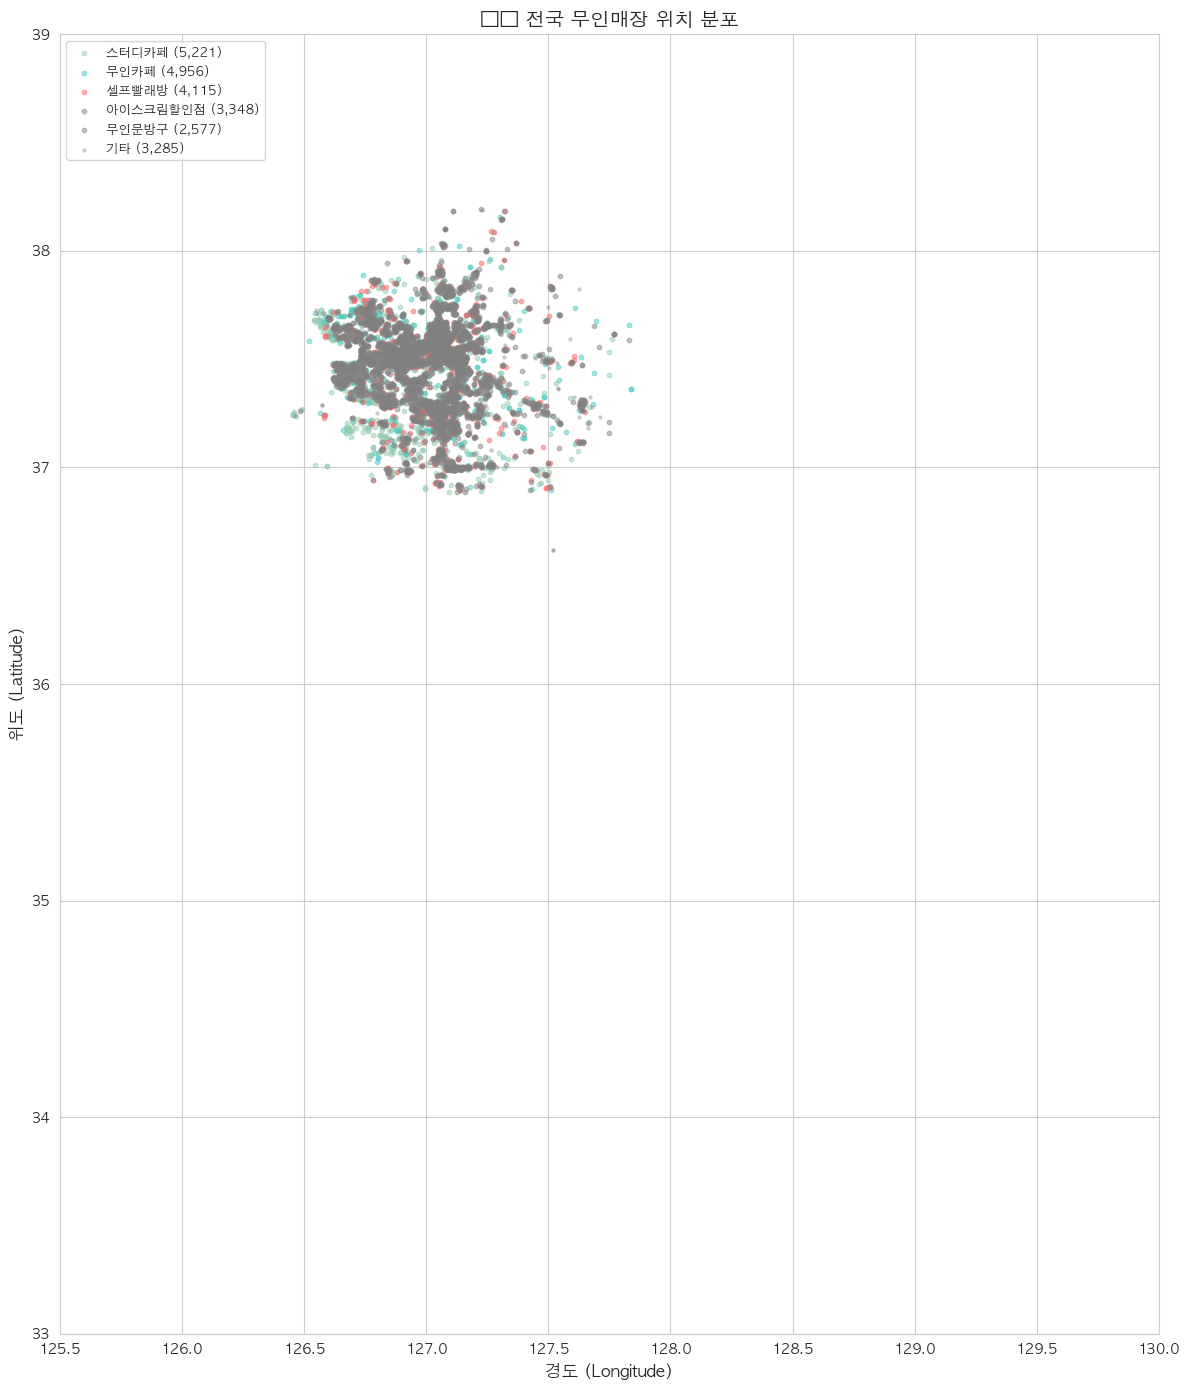

In [22]:
# 위경도가 있는 데이터만 필터링
df_geo = df[df['latitude'].notna() & df['longitude'].notna()].copy()
print(f"📍 위경도 정보가 있는 매장: {len(df_geo):,}개")

# 위경도 범위 확인
print(f"\n위도 범위: {df_geo['latitude'].min():.4f} ~ {df_geo['latitude'].max():.4f}")
print(f"경도 범위: {df_geo['longitude'].min():.4f} ~ {df_geo['longitude'].max():.4f}")

# 산점도로 전체 분포 확인
fig, ax = plt.subplots(figsize=(12, 14))

# 업종별로 색상 다르게
top5_cat = df_geo['category'].value_counts().head(5).index.tolist()
colors_map = {'셀프빨래방': '#FF6B6B', '무인카페': '#4ECDC4', '아이스크림': '#45B7D1', 
              '스터디카페': '#96CEB4', '무인점포': '#FFEAA7'}

for cat in top5_cat:
    df_temp = df_geo[df_geo['category'] == cat]
    color = colors_map.get(cat, '#888888')
    ax.scatter(df_temp['longitude'], df_temp['latitude'], 
               alpha=0.5, s=10, label=f'{cat} ({len(df_temp):,})', color=color)

# 기타 업종
df_others = df_geo[~df_geo['category'].isin(top5_cat)]
ax.scatter(df_others['longitude'], df_others['latitude'], 
           alpha=0.3, s=5, label=f'기타 ({len(df_others):,})', color='gray')

ax.set_xlabel('경도 (Longitude)', fontsize=12)
ax.set_ylabel('위도 (Latitude)', fontsize=12)
ax.set_title('🗺️ 전국 무인매장 위치 분포', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(125.5, 130)
ax.set_ylim(33, 39)

plt.tight_layout()
plt.show()

In [23]:
# Folium을 이용한 인터랙티브 지도 (설치 필요: pip install folium)
try:
    import folium
    from folium.plugins import MarkerCluster
    
    # 대한민국 중심 좌표
    center_lat = 36.5
    center_lon = 127.5
    
    # 지도 생성
    m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles='cartodbpositron')
    
    # 마커 클러스터 생성
    marker_cluster = MarkerCluster().add_to(m)
    
    # 샘플링 (전체 데이터가 너무 많으면 지도가 느려짐)
    sample_size = min(5000, len(df_geo))
    df_sample = df_geo.sample(n=sample_size, random_state=42)
    
    # 업종별 색상
    color_dict = {
        '셀프빨래방': 'red',
        '무인카페': 'blue',
        '아이스크림': 'green',
        '스터디카페': 'purple',
        '무인점포': 'orange'
    }
    
    # 마커 추가
    for _, row in df_sample.iterrows():
        color = color_dict.get(row['category'], 'gray')
        popup_text = f"""
        <b>{row['store_name']}</b><br>
        업종: {row['category']}<br>
        주소: {row['address']}<br>
        영업시간: {row.get('operation_time', 'N/A')}
        """
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5,
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7,
            popup=folium.Popup(popup_text, max_width=300)
        ).add_to(marker_cluster)
    
    # 범례 추가
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
                background-color: white; padding: 10px; border-radius: 5px;
                border: 2px solid gray;">
        <h4>업종 범례</h4>
        <p><span style="color:red;">●</span> 셀프빨래방</p>
        <p><span style="color:blue;">●</span> 무인카페</p>
        <p><span style="color:green;">●</span> 아이스크림</p>
        <p><span style="color:purple;">●</span> 스터디카페</p>
        <p><span style="color:orange;">●</span> 무인점포</p>
        <p><span style="color:gray;">●</span> 기타</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # HTML 파일로 저장
    m.save('brwnie_map.html')
    print(f"✅ 인터랙티브 지도가 'brwnie_map.html' 파일로 저장되었습니다.")
    print(f"   (샘플링: {sample_size:,}개 매장)")
    
    # 노트북에서 지도 표시
    m
    
except ImportError:
    print("❌ folium 라이브러리가 설치되어 있지 않습니다.")
    print("   설치: pip install folium")

✅ 인터랙티브 지도가 'brwnie_map.html' 파일로 저장되었습니다.
   (샘플링: 5,000개 매장)


## 9. 인사이트 요약

In [24]:
# 인사이트 자동 생성
print("=" * 70)
print("📊 브라우니 무인매장 데이터 분석 인사이트")
print("=" * 70)

# 1. 지역 인사이트
top3_si = df['si_address'].value_counts().head(3)
print(f"\n🏆 1. 무인매장이 가장 많은 지역 TOP 3:")
for i, (si, cnt) in enumerate(top3_si.items(), 1):
    print(f"   {i}위. {si}: {cnt:,}개 ({cnt/len(df)*100:.1f}%)")

# 2. 업종 인사이트
top3_cat = df['category'].value_counts().head(3)
print(f"\n🏪 2. 가장 인기있는 무인매장 업종 TOP 3:")
for i, (cat, cnt) in enumerate(top3_cat.items(), 1):
    print(f"   {i}위. {cat}: {cnt:,}개 ({cnt/len(df)*100:.1f}%)")

# 3. 서울 인사이트
if len(df_seoul) > 0:
    seoul_top_gu = df_seoul['goon_gu_address'].value_counts().head(3)
    print(f"\n📍 3. 서울시 무인매장 밀집 구 TOP 3:")
    for i, (gu, cnt) in enumerate(seoul_top_gu.items(), 1):
        print(f"   {i}위. {gu}: {cnt:,}개")

# 4. 경기도 인사이트
if len(df_gg) > 0:
    gg_top = df_gg['goon_gu_address'].value_counts().head(3)
    print(f"\n📍 4. 경기도 무인매장 밀집 시/군 TOP 3:")
    for i, (city, cnt) in enumerate(gg_top.items(), 1):
        print(f"   {i}위. {city}: {cnt:,}개")

# 5. 지역별 특화 업종
print(f"\n🎯 5. 지역별 1위 업종:")
for si in df['si_address'].value_counts().head(5).index:
    top_cat = df[df['si_address'] == si]['category'].value_counts().index[0]
    top_cnt = df[df['si_address'] == si]['category'].value_counts().values[0]
    print(f"   {si}: {top_cat} ({top_cnt:,}개)")

print("\n" + "=" * 70)
print("📁 생성된 파일:")
print("   - brwnie_stores.csv: 전체 매장 데이터")
print("   - brwnie_stores.json: 전체 매장 데이터 (JSON)")
print("   - brwnie_map.html: 인터랙티브 지도 (브라우저에서 열기)")
print("=" * 70)

📊 브라우니 무인매장 데이터 분석 인사이트

🏆 1. 무인매장이 가장 많은 지역 TOP 3:
   1위. 경기도: 14,298개 (60.8%)
   2위. 서울특별시: 6,957개 (29.6%)
   3위. 인천광역시: 1,695개 (7.2%)

🏪 2. 가장 인기있는 무인매장 업종 TOP 3:
   1위. 스터디카페: 5,221개 (22.2%)
   2위. 무인카페: 4,956개 (21.1%)
   3위. 셀프빨래방: 4,115개 (17.5%)

📍 3. 서울시 무인매장 밀집 구 TOP 3:
   1위. 송파구: 617개
   2위. 강서구: 457개
   3위. 강동구: 430개

📍 4. 경기도 무인매장 밀집 시/군 TOP 3:
   1위. 수원시: 1,339개
   2위. 화성시: 1,277개
   3위. 용인시: 1,198개

🎯 5. 지역별 1위 업종:
   경기도: 스터디카페 (3,380개)
   서울특별시: 무인카페 (1,454개)
   인천광역시: 무인카페 (399개)
   서울: 셀프빨래방 (74개)
   경기: 기타 (22개)

📁 생성된 파일:
   - brwnie_stores.csv: 전체 매장 데이터
   - brwnie_stores.json: 전체 매장 데이터 (JSON)
   - brwnie_map.html: 인터랙티브 지도 (브라우저에서 열기)
